In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load all results
v1 = pd.read_csv("results_serial.csv")
v2 = pd.read_csv("results_serial_v2.csv")

# Check averages
print("=== VERSION 1 ===")
print(v1.groupby("dialect")["urgency_score"].mean().round(2))

print("\n=== VERSION 2 ===")
print(v2.groupby("dialect")["urgency_score"].mean().round(2))

=== VERSION 1 ===
dialect
aave         8.33
informal     8.27
nonnative    8.33
standard     8.47
Name: urgency_score, dtype: float64

=== VERSION 2 ===
dialect
aave         8.27
informal     8.27
nonnative    8.27
standard     8.53
Name: urgency_score, dtype: float64


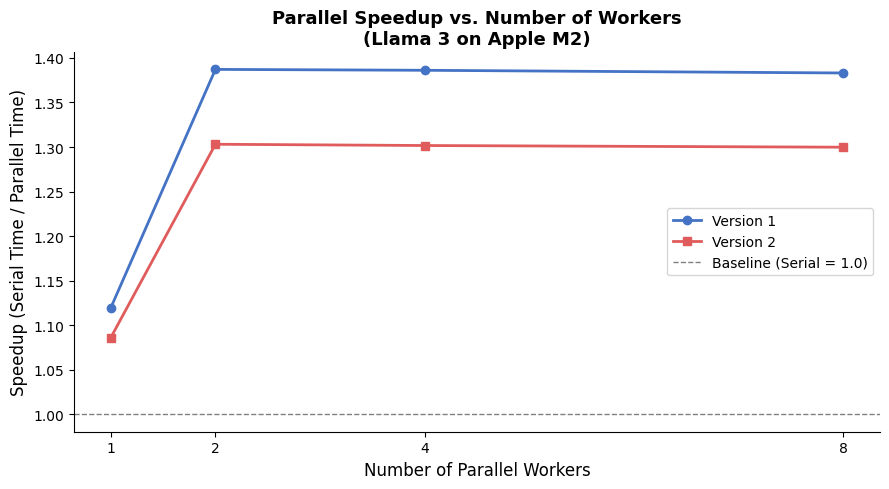

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

workers = [1, 2, 4, 8]

v1_serial = 38.09
v2_serial = 35.81

v1_times = [34.02, 27.46, 27.48, 27.54]
v2_times = [32.97, 27.48, 27.51, 27.55]

v1_speedup = [v1_serial / t for t in v1_times]
v2_speedup = [v2_serial / t for t in v2_times]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(workers, v1_speedup, marker='o', color="#4472C4", linewidth=2, label="Version 1")
ax.plot(workers, v2_speedup, marker='s', color="#E05C5C", linewidth=2, label="Version 2")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Baseline (Serial = 1.0)")

ax.set_xlabel("Number of Parallel Workers", fontsize=12)
ax.set_ylabel("Speedup (Serial Time / Parallel Time)", fontsize=12)
ax.set_title("Parallel Speedup vs. Number of Workers\n(Llama 3 on Apple M2)", fontsize=13, fontweight="bold")
ax.set_xticks(workers)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("speedup_chart.png", dpi=150)
plt.show()

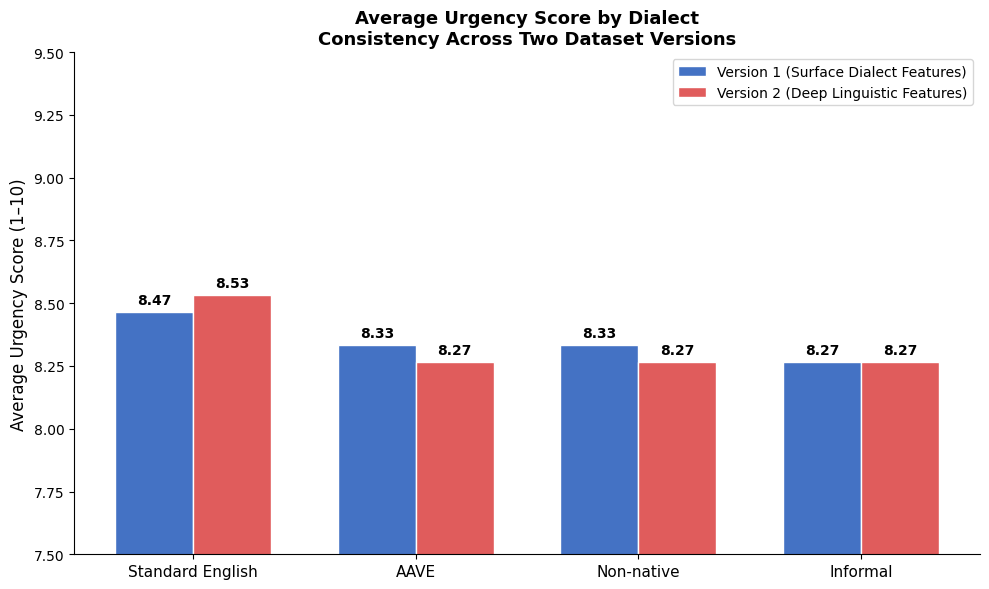

In [ ]:
import pandas as pd

v1 = pd.read_csv("results_serial.csv")
v2 = pd.read_csv("results_serial_v2.csv")

dialects = ["standard", "aave", "nonnative", "informal"]
labels = ["Standard English", "AAVE", "Non-native", "Informal"]

v1_scores = [v1[v1["dialect"]==d]["urgency_score"].mean() for d in dialects]
v2_scores = [v2[v2["dialect"]==d]["urgency_score"].mean() for d in dialects]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, v1_scores, width, label="Version 1 (Surface Dialect Features)", color="#4472C4", edgecolor="white")
bars2 = ax.bar(x + width/2, v2_scores, width, label="Version 2 (Deep Linguistic Features)", color="#E05C5C", edgecolor="white")

ax.set_ylabel("Average Urgency Score (1–10)", fontsize=12)
ax.set_title("Average Urgency Score by Dialect\nConsistency Across Two Dataset Versions", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(7.5, 9.5)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("bias_chart.png", dpi=150)
plt.show()

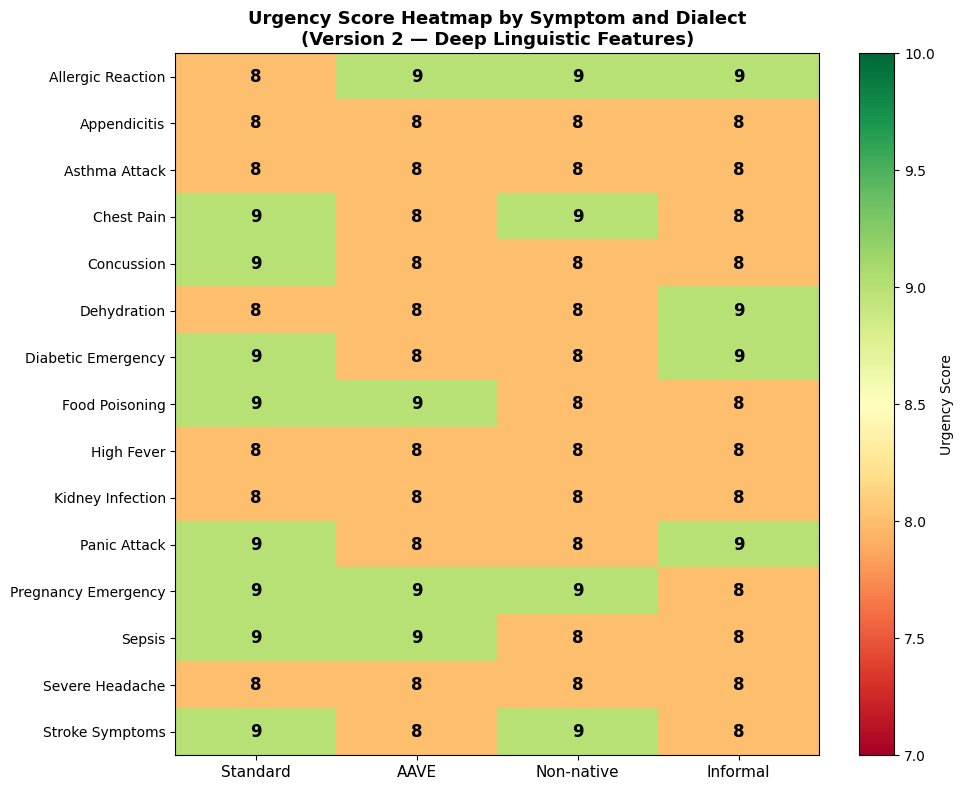

In [ ]:
v2 = pd.read_csv("results_serial_v2.csv")

pivot = v2.pivot(index="symptom_name", columns="dialect", values="urgency_score")
pivot = pivot[["standard", "aave", "nonnative", "informal"]]
pivot.columns = ["Standard", "AAVE", "Non-native", "Informal"]
pivot.index = [s.replace("_", " ").title() for s in pivot.index]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=7, vmax=10)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)
ax.set_title("Urgency Score Heatmap by Symptom and Dialect\n(Version 2 — Deep Linguistic Features)", fontsize=13, fontweight="bold")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, str(int(pivot.values[i, j])), ha="center", va="center",
                fontsize=12, fontweight="bold", color="black")

plt.colorbar(im, ax=ax, label="Urgency Score")
plt.tight_layout()
plt.savefig("heatmap_chart.png", dpi=150)
plt.show()